# Phase 2 — Exploratory Data Analysis & Hypothesis Testing

Dataset used: `data/processed/nyc_air_weather_traffic_2023_daily.csv`

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (10,4)

df = pd.read_csv("../data/processed/nyc_air_weather_traffic_2023_daily.csv", parse_dates=["date"])
df.head()

,date,pm25,temp_mean,humidity_mean,wind_speed_mean,precip_mm,traffic_volume,weekday,is_weekend,traffic_level
0,2023-01-07,5.355729,3.4,NaN,9.8,0.0,913,5,True,low
1,2023-01-08,5.494271,0.8,NaN,8.1,0.2,12987,6,True,high
2,2023-01-09,9.529444,3.2,NaN,9.4,0.3,15315,0,False,high
3,2023-01-10,10.504687,2.7,NaN,11.1,0.7,454,1,False,low
4,2023-01-14,4.040104,1.1,NaN,10.4,0.0,9767,5,True,low


## 1. Basic Info & Sanity Checks

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             170 non-null    datetime64[ns]
 1   pm25             170 non-null    float64       
 2   temp_mean        170 non-null    float64       
 3   humidity_mean    0 non-null      float64       
 4   wind_speed_mean  170 non-null    float64       
 5   precip_mm        170 non-null    float64       
 6   traffic_volume   170 non-null    int64         
 7   weekday          170 non-null    int64         
 8   is_weekend       170 non-null    bool          
 9   traffic_level    170 non-null    object        
dtypes: bool(1), datetime64[ns](1), float64(5), int64(2), object(1)
memory usage: 12.2+ KB


In [48]:
df.describe(include="all")

,date,pm25,temp_mean,humidity_mean,wind_speed_mean,precip_mm,traffic_volume,weekday,is_weekend,traffic_level
count,170,170.000000,170.000000,0.0,170.000000,170.000000,170.000000,170.000000,170,170
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122,85
mean,2023-07-01 16:31:03.529411840,11.209244,15.240588,NaN,10.781176,2.738824,25047.247059,2.888235,NaN,NaN
min,2023-01-07 00:00:00,2.172396,-8.000000,NaN,4.400000,0.000000,0.000000,0.000000,NaN,NaN
25%,2023-04-29 06:00:00,4.989577,10.525000,NaN,7.525000,0.000000,4147.000000,1.000000,NaN,NaN
50%,2023-06-13 12:00:00,7.345069,16.050000,NaN,9.450000,0.000000,10140.500000,3.000000,NaN,NaN
75%,2023-10-01 18:00:00,12.081424,20.700000,NaN,12.350000,0.925000,31544.250000,5.000000,NaN,NaN
max,2023-12-10 00:00:00,189.993909,25.900000,NaN,39.100000,41.300000,187218.000000,6.000000,NaN,NaN


In [49]:
df.isna().sum()

date                 0
pm25                 0
temp_mean            0
humidity_mean      170
wind_speed_mean      0
precip_mm            0
traffic_volume       0
weekday              0
is_weekend           0
traffic_level        0
dtype: int64

## 2. Univariate EDA

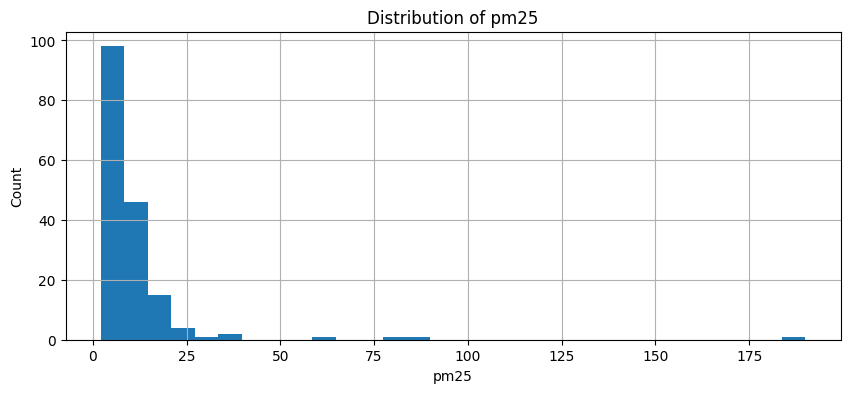

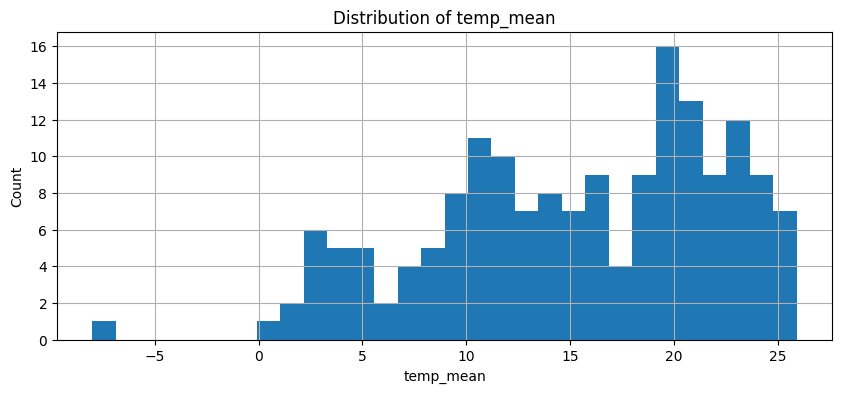

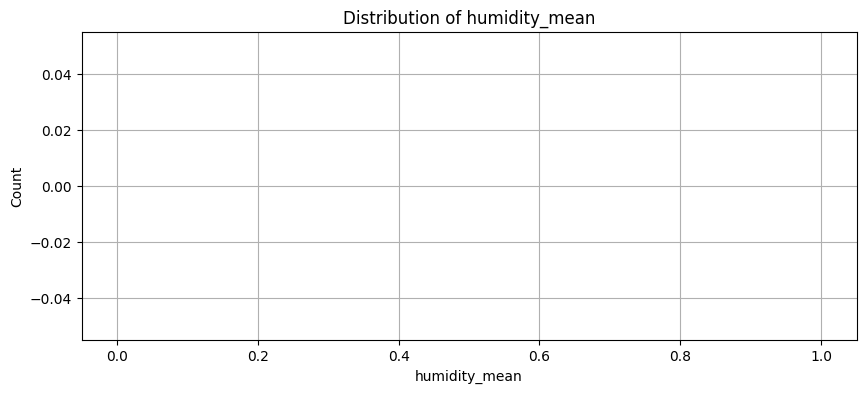

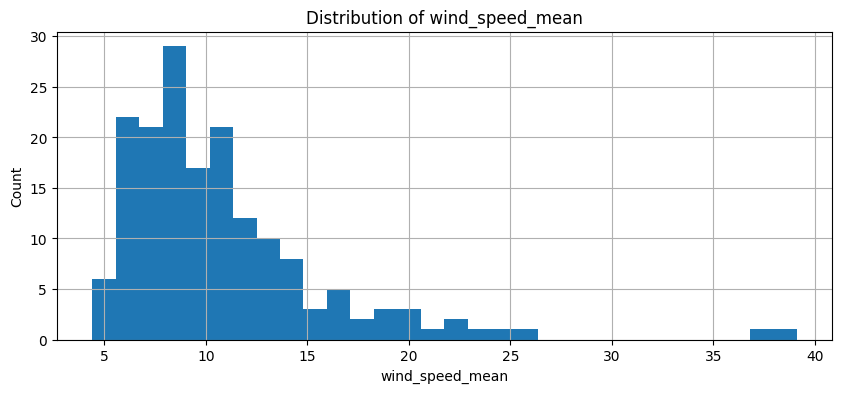

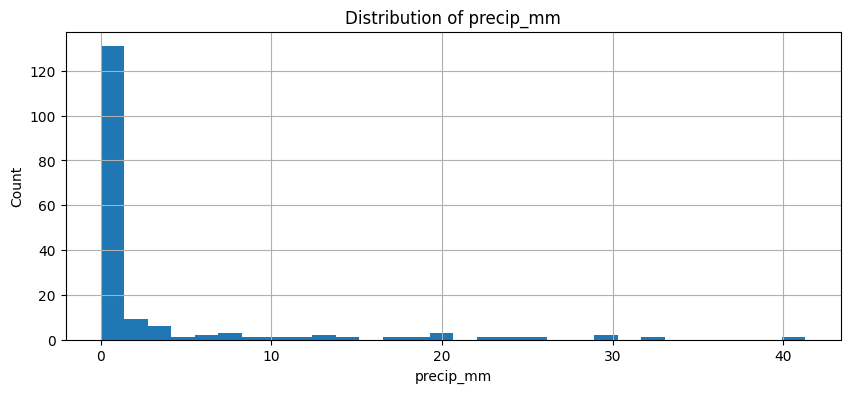

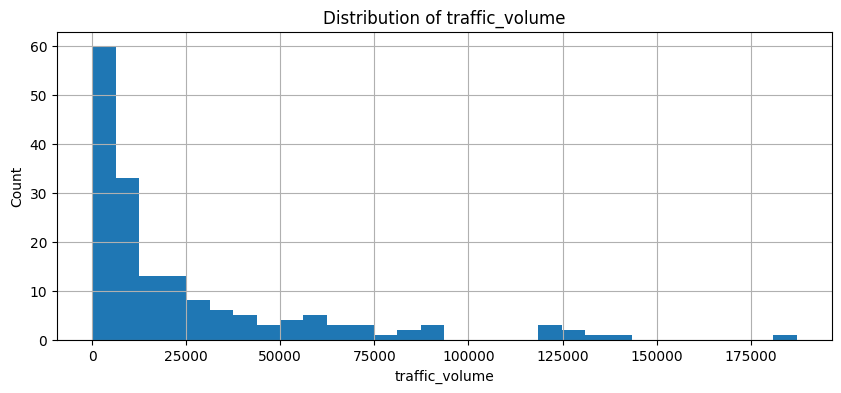

In [50]:
numeric_cols = ["pm25", "temp_mean", "humidity_mean", "wind_speed_mean", "precip_mm", "traffic_volume"]

for col in numeric_cols:
    if col in df.columns:
        plt.figure()
        df[col].hist(bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

### PM2.5 Time Series

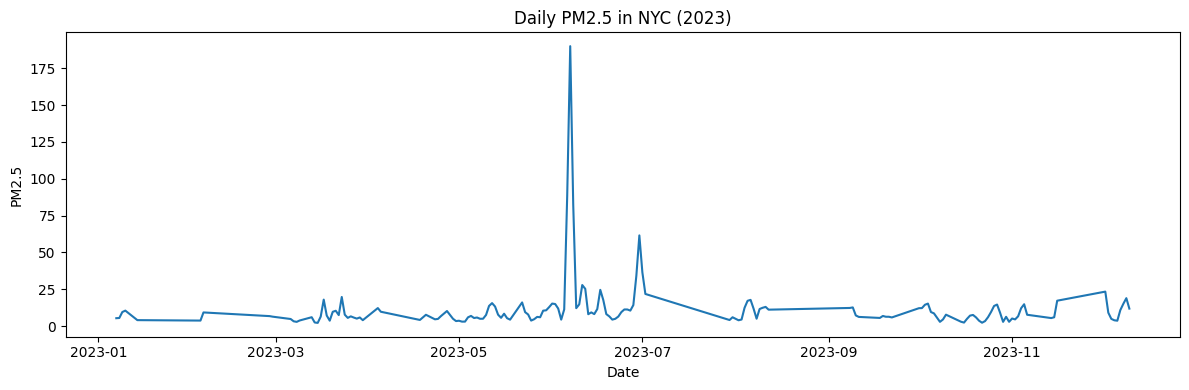

In [51]:
df_sorted = df.sort_values("date")

plt.figure(figsize=(12,4))
plt.plot(df_sorted["date"], df_sorted["pm25"])
plt.title("Daily PM2.5 in NYC (2023)")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()

## 3. Bivariate EDA

### PM2.5 vs Traffic Volume

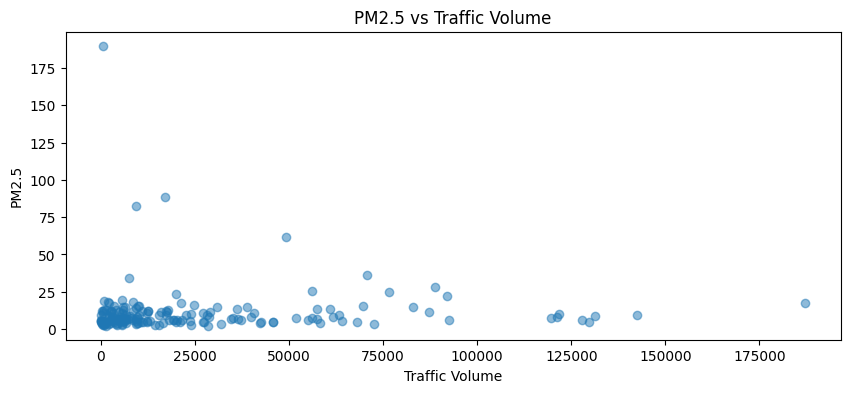

In [52]:
plt.scatter(df["traffic_volume"], df["pm25"], alpha=0.5)
plt.xlabel("Traffic Volume")
plt.ylabel("PM2.5")
plt.title("PM2.5 vs Traffic Volume")
plt.show()

### Correlation Matrix

In [53]:
cols = [c for c in ["pm25", "temp_mean", "humidity_mean", "wind_speed_mean", "precip_mm", "traffic_volume"] if c in df.columns]
corr = df[cols].corr(method="pearson")
corr

,pm25,temp_mean,humidity_mean,wind_speed_mean,precip_mm,traffic_volume
pm25,1.000000,0.213454,NaN,-0.219642,-0.066016,0.012577
temp_mean,0.213454,1.000000,NaN,-0.324104,0.076504,0.182557
humidity_mean,NaN,NaN,NaN,NaN,NaN,NaN
wind_speed_mean,-0.219642,-0.324104,NaN,1.000000,0.121798,-0.162670
precip_mm,-0.066016,0.076504,NaN,0.121798,1.000000,-0.059355
traffic_volume,0.012577,0.182557,NaN,-0.162670,-0.059355,1.000000


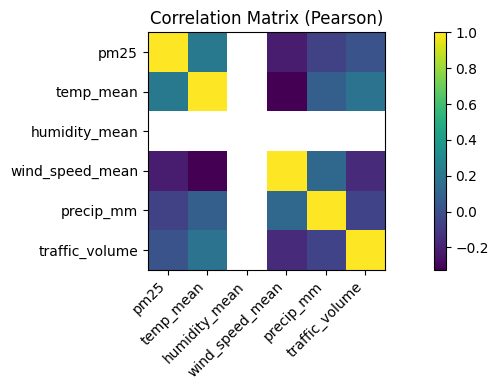

In [54]:
fig, ax = plt.subplots()
cax = ax.imshow(corr, interpolation="nearest")
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)
fig.colorbar(cax)
plt.title("Correlation Matrix (Pearson)")
plt.tight_layout()
plt.show()

## 4. Prepare Group Variables (Weekend & Traffic Level)

In [55]:
if "weekday" not in df.columns:
    df["weekday"] = df["date"].dt.weekday

if "is_weekend" not in df.columns:
    df["is_weekend"] = df["weekday"] >= 5

if "traffic_level" not in df.columns:
    median_traffic = df["traffic_volume"].median()
    df["traffic_level"] = np.where(df["traffic_volume"] > median_traffic, "high", "low")

df.head()

,date,pm25,temp_mean,humidity_mean,wind_speed_mean,precip_mm,traffic_volume,weekday,is_weekend,traffic_level
0,2023-01-07,5.355729,3.4,NaN,9.8,0.0,913,5,True,low
1,2023-01-08,5.494271,0.8,NaN,8.1,0.2,12987,6,True,high
2,2023-01-09,9.529444,3.2,NaN,9.4,0.3,15315,0,False,high
3,2023-01-10,10.504687,2.7,NaN,11.1,0.7,454,1,False,low
4,2023-01-14,4.040104,1.1,NaN,10.4,0.0,9767,5,True,low


## 5. H1 — PM2.5 vs Weather Variables (Correlation Tests)

In [56]:
weather_vars = [v for v in ["temp_mean", "humidity_mean", "wind_speed_mean", "precip_mm"] if v in df.columns]

for var in weather_vars:
    sub = df[["pm25", var]].dropna()
    if len(sub) < 10:
        print(f"{var}: not enough data for test")
        continue
    r, p = stats.pearsonr(sub["pm25"], sub[var])
    print(f"{var}: Pearson r = {r:.3f}, p = {p:.4g}, n = {len(sub)}")

temp_mean: Pearson r = 0.213, p = 0.005192, n = 170
humidity_mean: not enough data for test
wind_speed_mean: Pearson r = -0.220, p = 0.004004, n = 170
precip_mm: Pearson r = -0.066, p = 0.3924, n = 170


## 6. H2 — High vs Low Traffic Days (t-test & Mann–Whitney)

In [57]:
high = df.loc[df["traffic_level"] == "high", "pm25"].dropna()
low  = df.loc[df["traffic_level"] == "low",  "pm25"].dropna()

print("High mean:", high.mean())
print("Low mean:", low.mean())

t_stat, p_t = stats.ttest_ind(high, low, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(high, low, alternative="two-sided")

print(f"t-test p = {p_t:.4g}")
print(f"Mann–Whitney p = {p_u:.4g}")

High mean: 11.031302288189444
Low mean: 11.387185427734087
t-test p = 0.8952
Mann–Whitney p = 0.2936


### Boxplot (High vs Low Traffic)

C:\Users\Kerem\AppData\Local\Temp\ipykernel_1428\37267863.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low.values, high.values], labels=["low", "high"])


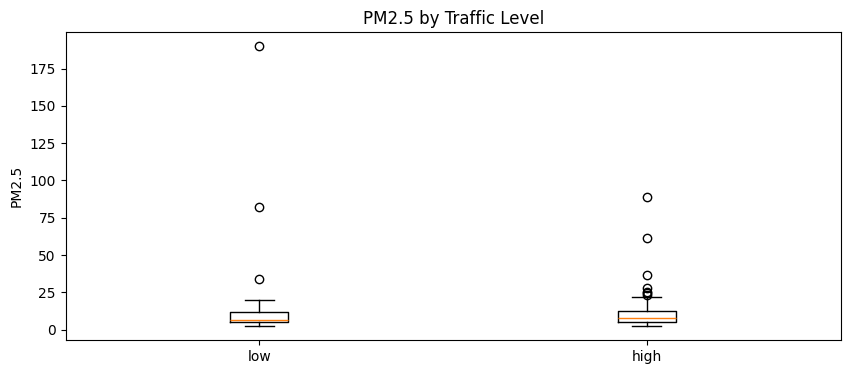

In [58]:
plt.boxplot([low.values, high.values], labels=["low", "high"])
plt.ylabel("PM2.5")
plt.title("PM2.5 by Traffic Level")
plt.show()

## 7. H3 — Weekday vs Weekend (t-test & Mann–Whitney)

In [59]:
weekend = df.loc[df["is_weekend"], "pm25"].dropna()
weekday = df.loc[~df["is_weekend"], "pm25"].dropna()

print("Weekday mean:", weekday.mean())
print("Weekend mean:", weekend.mean())

t_stat, p_t = stats.ttest_ind(weekday, weekend, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(weekday, weekend, alternative="two-sided")

print(f"t-test p = {p_t:.4g}")
print(f"Mann–Whitney p = {p_u:.4g}")

Weekday mean: 11.602831085817929
Weekend mean: 10.208876320494019
t-test p = 0.5115
Mann–Whitney p = 0.762


### Boxplot (Weekday vs Weekend)

C:\Users\Kerem\AppData\Local\Temp\ipykernel_1428\1868518885.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([weekday.values, weekend.values], labels=["weekday", "weekend"])


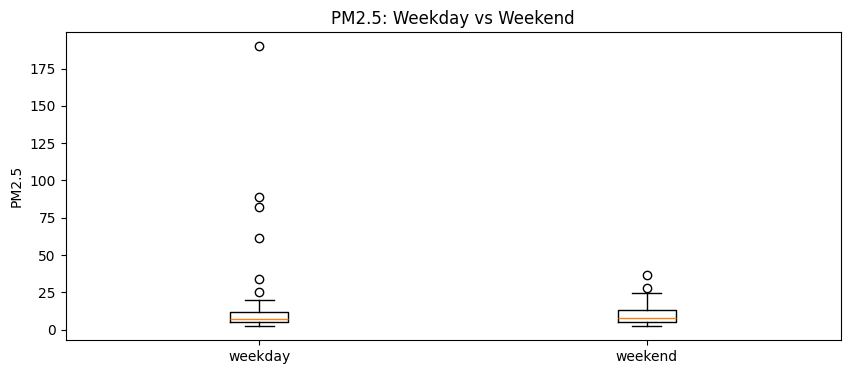

In [60]:
plt.boxplot([weekday.values, weekend.values], labels=["weekday", "weekend"])
plt.ylabel("PM2.5")
plt.title("PM2.5: Weekday vs Weekend")
plt.show()